# EconIQ: Food Price Forecasting

The goal of this project is to predict the food price for the following month using historical food prices, economic indicators, weather information, and commodity type.

We will compare:
- Naive forecasting
- Random Forest
- XGBoost

The dataset contains food-price observations for different commodities in Kenya.

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import joblib
import json

pd.set_option("display.max_columns", None)

In [216]:
df = pd.read_csv(
    "../data/processed/food_price_prediction.csv",
    parse_dates=["date", "target_date"]
)

df.head()

,date,commodity,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
0,2006-01-01,Beans (dry),39.0,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,39.00,39.00,NaN,42.0,2006-02-01
1,2006-01-01,Maize (white),23.5,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,23.50,23.50,NaN,25.0,2006-02-01
2,2006-01-01,Oil (vegetable),115.0,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,115.00,115.00,NaN,120.0,2006-02-01
3,2006-02-01,Beans (dry),42.0,9.01,9.39,9.258021,0.854813,25.384639,32.413195,19.443096,58.030785,3.961852,39.0,NaN,NaN,NaN,3.0,40.50,40.50,-0.03837,47.0,2006-03-01
4,2006-02-01,Maize (white),25.0,9.01,9.39,9.258021,0.854813,25.384639,32.413195,19.443096,58.030785,3.961852,23.5,NaN,NaN,NaN,1.5,24.25,24.25,-0.03837,24.5,2006-03-01


In [125]:
df.tail()

,date,commodity,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
1873,2026-07-01,Rice,118.865,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,129.820,125.0,111.52,128.0,-10.955,121.958333,118.825833,1.034965,120.000,2026-08-01
1874,2026-07-01,Salt,15.000,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,14.635,15.0,13.79,10.0,0.365,13.638333,13.795833,1.034965,15.000,2026-08-01
1875,2026-07-01,Sorghum,45.000,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,50.000,85.0,80.00,75.0,-5.000,65.000000,74.953333,1.034965,44.165,2026-08-01
1876,2026-07-01,Sugar,154.720,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,150.000,150.0,116.60,162.0,4.720,141.883333,141.458333,1.034965,157.500,2026-08-01
1877,2026-07-01,Wheat flour,91.390,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,92.915,90.0,99.57,82.0,-1.525,94.351667,95.509167,1.034965,90.555,2026-08-01


In [126]:
print(df.shape)
print(df.info())

(1878, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878 entries, 0 to 1877
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          1878 non-null   datetime64[ns]
 1   commodity                     1878 non-null   object        
 2   food_price                    1878 non-null   float64       
 3   inflation_annual_avg          1878 non-null   float64       
 4   inflation_12m                 1878 non-null   float64       
 5   central_bank_rate             1878 non-null   float64       
 6   rainfall                      1878 non-null   float64       
 7   temperature                   1878 non-null   float64       
 8   temperature_max               1878 non-null   float64       
 9   temperature_min               1878 non-null   float64       
 10  humidity                      1878 non-null   float64       
 11  wind_speed         

In [127]:
df.describe()

,date,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
count,1878,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1856.000000,1817.000000,1740.000000,1587.000000,1856.000000,1878.000000,1878.000000,1853.000000,1878.000000,1878
mean,2020-10-15 01:43:30.862619648,1414.154036,6.333860,6.279414,9.547306,2.298719,23.951953,30.108134,19.003799,66.067181,4.223519,1397.665935,1364.743531,1321.459305,1246.917092,13.274291,1400.507248,1383.975987,0.020580,1420.179494,2020-11-14 11:35:27.795527168
min,2006-01-01 00:00:00,9.890000,3.550000,1.850000,5.750000,0.120000,21.694516,27.348452,16.916645,51.113643,3.127290,8.000000,8.000000,8.000000,8.000000,-5750.400000,9.333333,9.500000,-3.500000,9.890000,2006-02-01 00:00:00
25%,2018-12-01 00:00:00,66.516250,4.660000,4.470000,8.250000,1.055613,23.023067,28.840667,18.206667,62.014515,3.949293,65.776250,65.600000,65.000000,65.000000,-5.000000,67.718333,67.950000,0.000000,68.240000,2019-01-01 00:00:00
50%,2022-10-01 00:00:00,135.000000,5.770000,5.800000,9.500000,1.658513,24.137874,30.013344,19.169279,66.317172,4.220570,135.000000,130.000000,130.000000,127.000000,0.000000,134.725833,133.333333,0.000000,135.000000,2022-11-01 00:00:00
75%,2024-08-01 00:00:00,700.000000,7.395000,6.860000,10.500000,2.883667,24.632600,31.214093,19.674600,69.224323,4.559032,700.000000,667.500000,628.907500,600.000000,6.712500,697.801667,697.916667,0.000000,700.000000,2024-09-01 00:00:00
max,2026-07-01 00:00:00,15717.000000,17.070000,19.720000,18.000000,9.333467,26.167613,33.591613,20.995677,78.724933,5.136800,16342.200000,16342.200000,16342.200000,15717.000000,6468.480000,15467.350000,14982.508333,5.500000,16342.200000,2026-08-01 00:00:00
std,NaN,2807.368671,2.408273,2.765275,2.161785,1.799270,1.072486,1.471869,0.917936,5.569413,0.409421,2793.388124,2760.427905,2712.103428,2618.975405,512.075934,2767.076362,2732.690116,0.594374,2822.194913,NaN


In [128]:
df.isnull().sum().sort_values(ascending=False)

food_price_lag_12               291
food_price_lag_6                138
food_price_lag_3                 61
central_bank_rate_change_1m      25
food_price_lag_1                 22
food_price_change_1m             22
central_bank_rate                 0
inflation_12m                     0
inflation_annual_avg              0
food_price                        0
commodity                         0
date                              0
rainfall                          0
temperature                       0
humidity                          0
wind_speed                        0
temperature_max                   0
temperature_min                   0
food_price_ma_3                   0
food_price_ma_6                   0
target_food_price_next_month      0
target_date                       0
dtype: int64

In [129]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percentage": df.isnull().mean() * 100
})

missing[missing["missing"] > 0]

,missing,percentage
food_price_lag_1,22,1.171459
food_price_lag_3,61,3.248136
food_price_lag_6,138,7.348243
food_price_lag_12,291,15.495208
food_price_change_1m,22,1.171459
central_bank_rate_change_1m,25,1.331203


In [130]:
df.duplicated().sum()

np.int64(0)

In [131]:
df.duplicated(subset=["date", "commodity"]).sum()

np.int64(0)

In [132]:
print("Start date:", df["date"].min().date())
print("End date:", df["date"].max().date())
print("Number of months:", df["date"].nunique())

Start date: 2006-01-01
End date: 2026-07-01
Number of months: 247


In [133]:
df["commodity"].nunique()

26

In [134]:
df["commodity"].unique()

array(['Beans (dry)', 'Maize (white)', 'Oil (vegetable)', 'Bananas',
       'Maize flour', 'Potatoes (Irish)', 'Rice', 'Salt', 'Sugar',
       'Wheat flour', 'Beans (dolichos)', 'Beans (rosecoco)', 'Cowpeas',
       'Maize', 'Maize (white, dry)', 'Meat (beef)', 'Meat (camel)',
       'Meat (goat)', 'Milk (camel, fresh)', 'Milk (UHT)', 'Onions (dry)',
       'Potatoes (Irish, red)', 'Potatoes (Irish, white)',
       'Rice (aromatic)', 'Sorghum', 'Tomatoes'], dtype=object)

## EDA

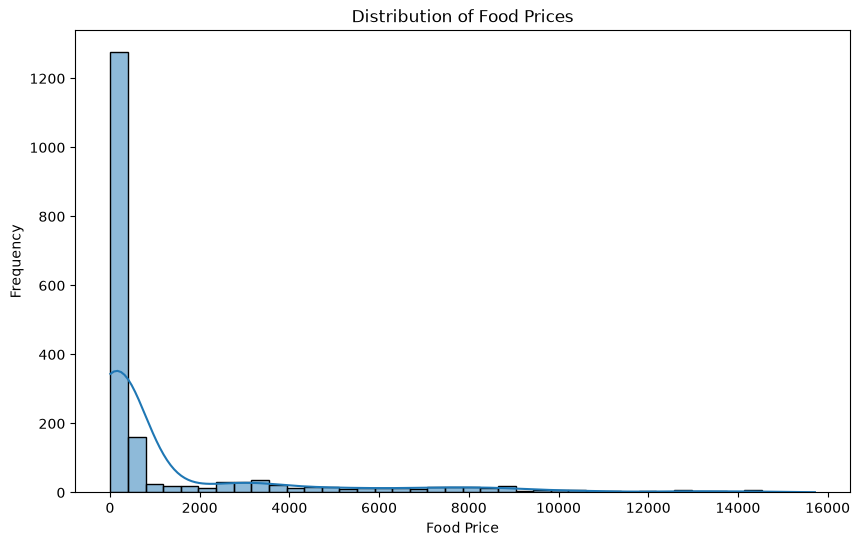

In [135]:
# Food Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["food_price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Food Prices")
plt.xlabel("Food Price")
plt.ylabel("Frequency")

plt.show()

In [136]:
df["food_price"].describe()

count     1878.000000
mean      1414.154036
std       2807.368671
min          9.890000
25%         66.516250
50%        135.000000
75%        700.000000
max      15717.000000
Name: food_price, dtype: float64

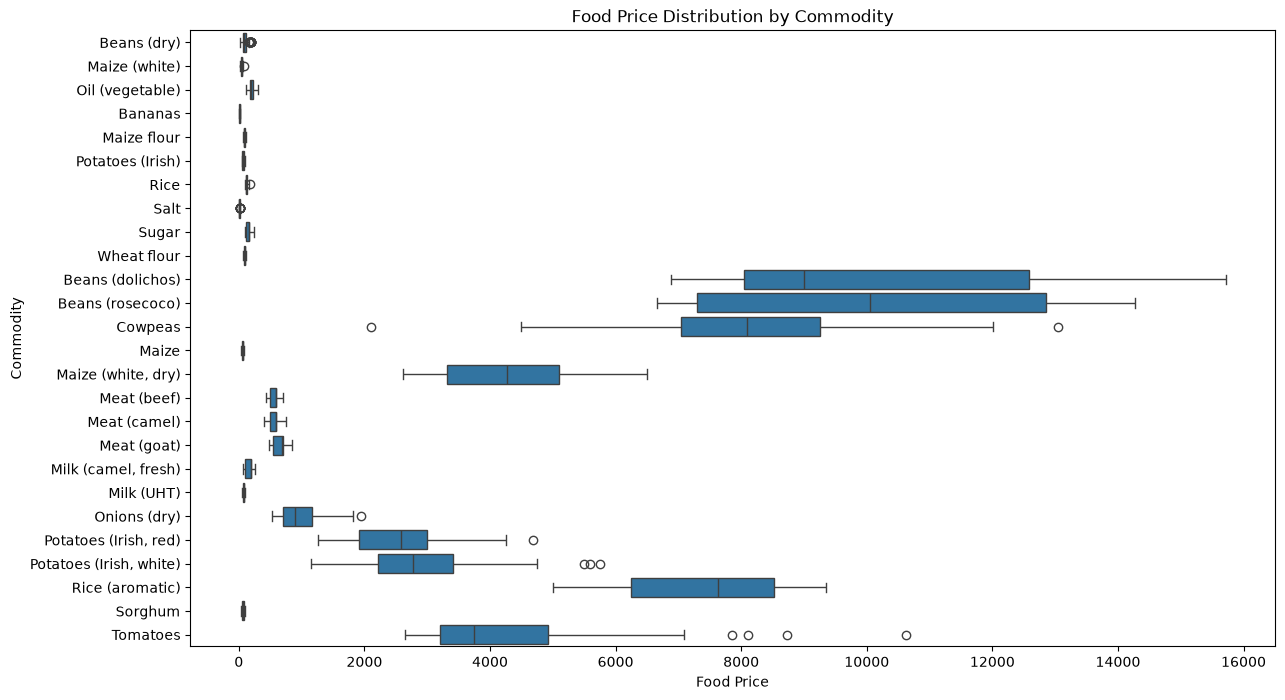

In [137]:
# Food Prices by Commodity

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df,
    x="food_price",
    y="commodity"
)

plt.title("Food Price Distribution by Commodity")
plt.xlabel("Food Price")
plt.ylabel("Commodity")

plt.show()

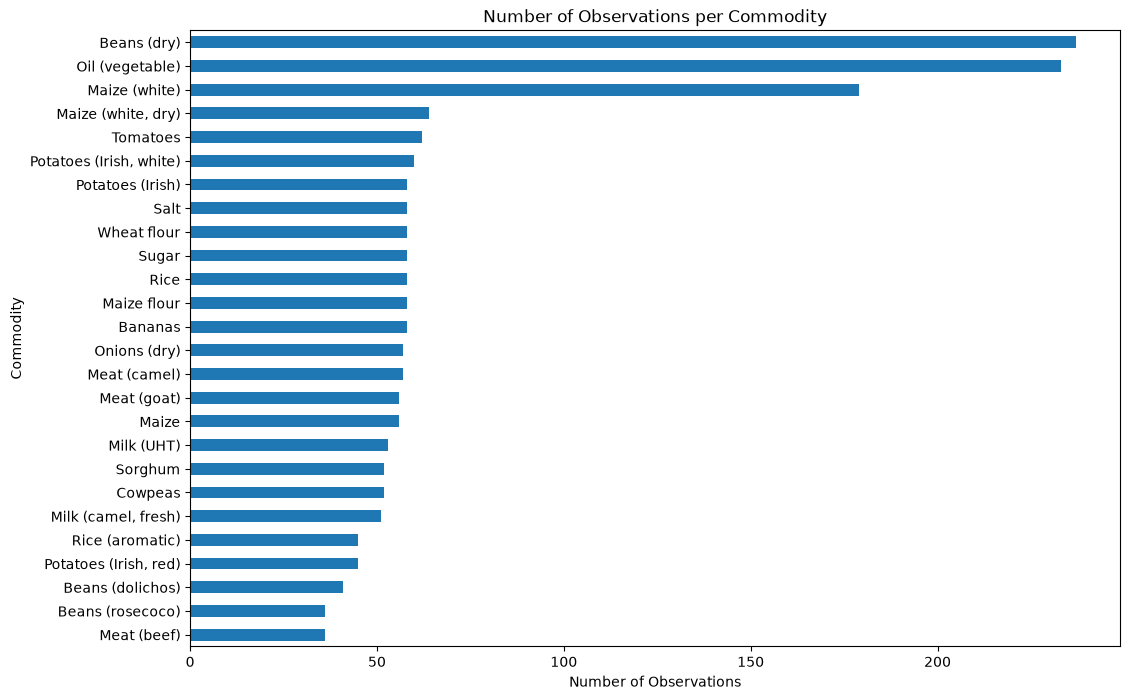

In [138]:
#  Number of Observations per Commodity

commodity_counts = df["commodity"].value_counts()

plt.figure(figsize=(12, 8))

commodity_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Observations per Commodity")
plt.xlabel("Number of Observations")
plt.ylabel("Commodity")

plt.show()

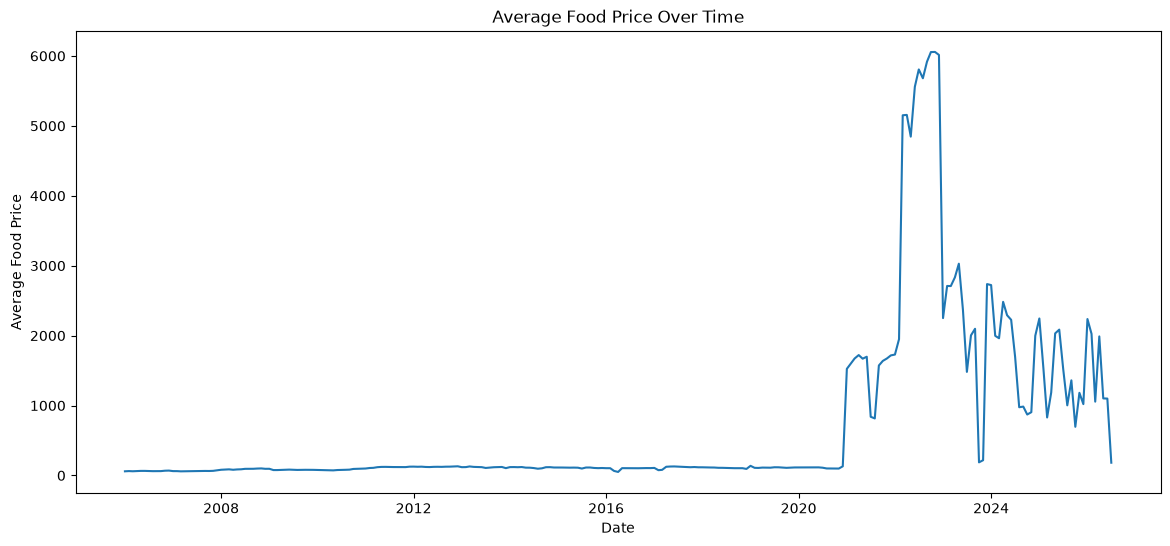

In [139]:
# Food Prices Over Time

monthly_prices = (
    df.groupby("date")["food_price"]
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_prices.index,
    monthly_prices.values
)

plt.title("Average Food Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Food Price")

plt.show()

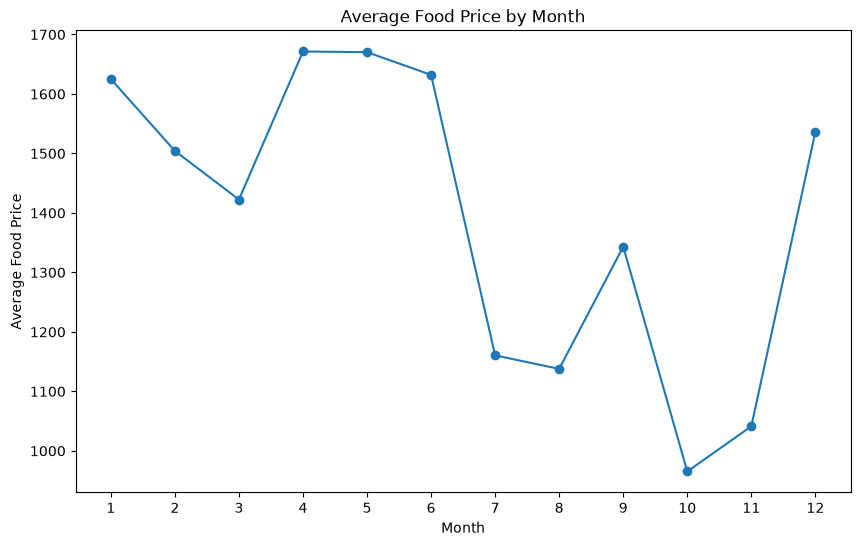

In [140]:
# Seasonality

df["month"] = df["date"].dt.month

monthly_seasonality = (
    df.groupby("month")["food_price"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Food Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Food Price")

plt.xticks(range(1, 13))

plt.show()

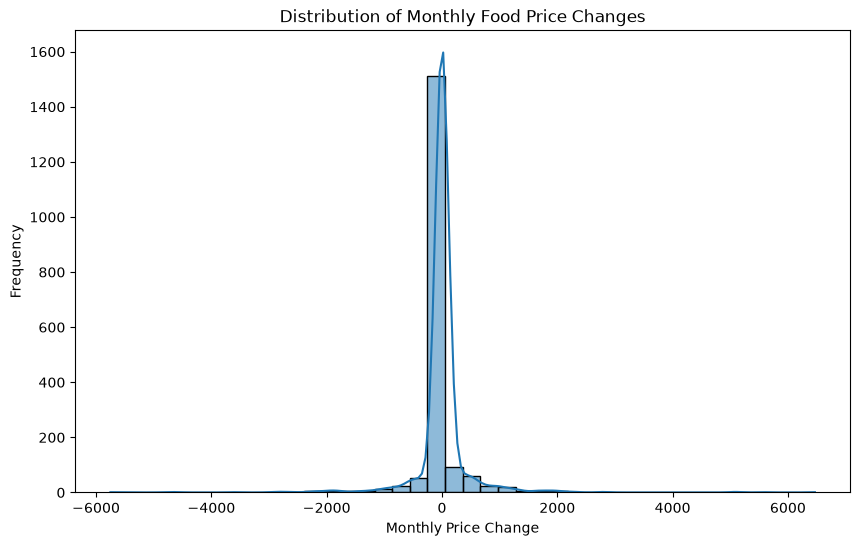

In [141]:
# Monthly Food Price Changes

plt.figure(figsize=(10, 6))

sns.histplot(
    df["food_price_change_1m"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Monthly Food Price Changes")
plt.xlabel("Monthly Price Change")
plt.ylabel("Frequency")

plt.show()

In [142]:
df["food_price_change_1m"].describe()

count    1856.000000
mean       13.274291
std       512.075934
min     -5750.400000
25%        -5.000000
50%         0.000000
75%         6.712500
max      6468.480000
Name: food_price_change_1m, dtype: float64

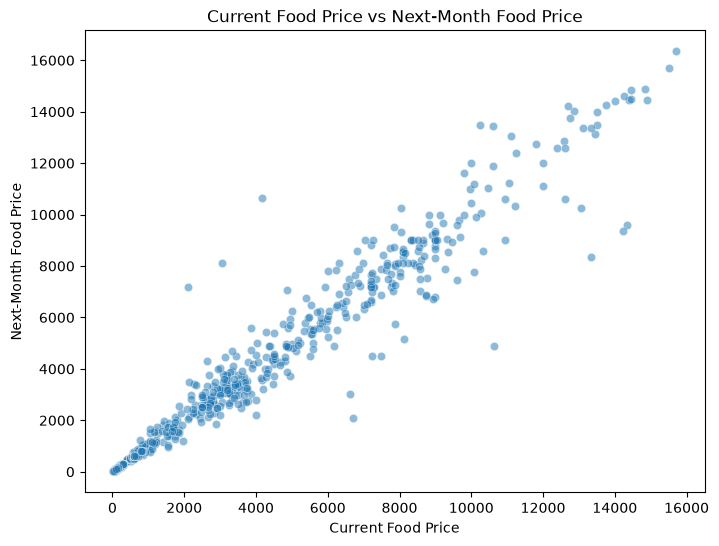

In [143]:
# Current Food Price vs Next-Month Food Price

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="food_price",
    y="target_food_price_next_month",
    alpha=0.5
)

plt.title("Current Food Price vs Next-Month Food Price")
plt.xlabel("Current Food Price")
plt.ylabel("Next-Month Food Price")

plt.show()

In [144]:
df[
    ["food_price", "target_food_price_next_month"]
].corr()

,food_price,target_food_price_next_month
food_price,1.000000,0.983343
target_food_price_next_month,0.983343,1.000000


In [145]:
#  Historical Price Features

lag_features = [
    "food_price",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_ma_3",
    "food_price_ma_6",
    "food_price_change_1m"
]

lag_correlations = (
    df[lag_features + ["target_food_price_next_month"]]
    .corr()["target_food_price_next_month"]
    .sort_values(ascending=False)
)

lag_correlations

target_food_price_next_month    1.000000
food_price                      0.983343
food_price_ma_3                 0.981507
food_price_ma_6                 0.975838
food_price_lag_1                0.973773
food_price_lag_3                0.961608
food_price_lag_6                0.947488
food_price_lag_12               0.914119
food_price_change_1m            0.085087
Name: target_food_price_next_month, dtype: float64

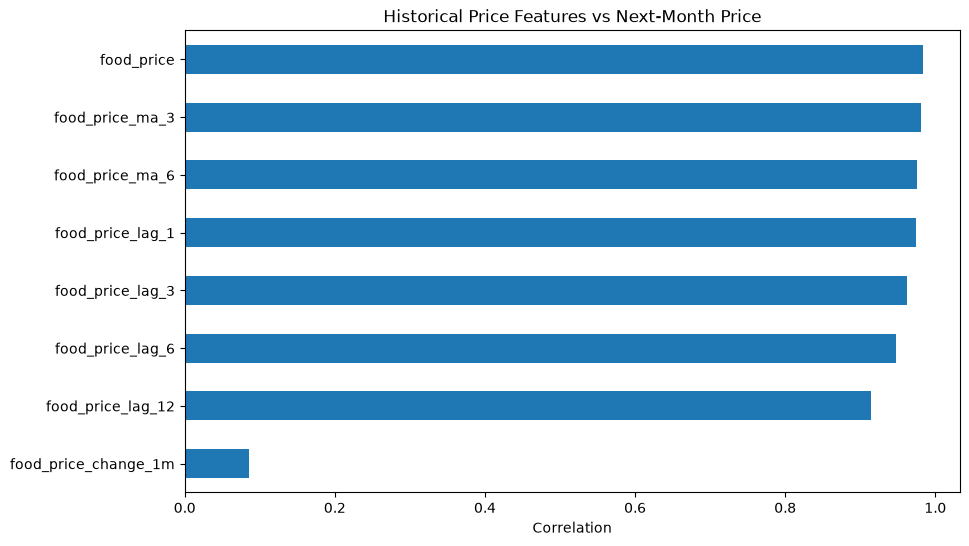

In [146]:
plt.figure(figsize=(10, 6))

lag_correlations.drop(
    "target_food_price_next_month"
).sort_values().plot(
    kind="barh"
)

plt.title("Historical Price Features vs Next-Month Price")
plt.xlabel("Correlation")

plt.show()

In [147]:
#  Correlation Matrix

numeric_columns = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_columns].corr()

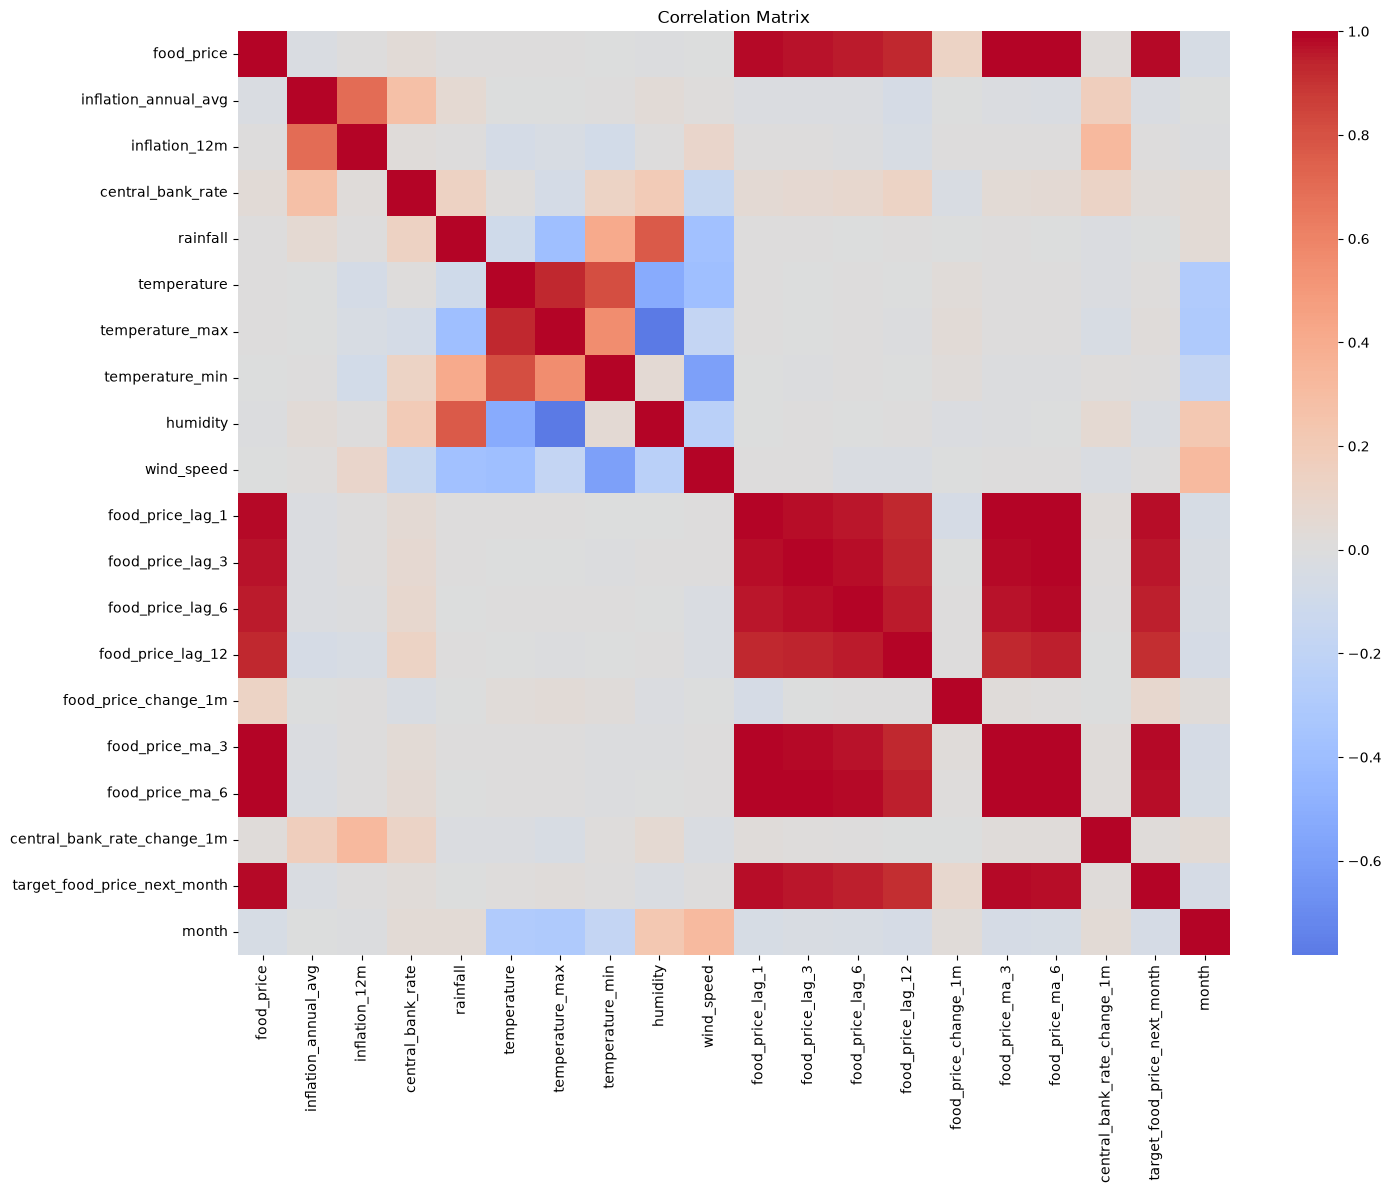

In [148]:
plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, cmap="coolwarm", center=0 )

plt.title("Correlation Matrix")

plt.show()

In [149]:
# Weather

weather_features = [
    "rainfall",
    "temperature",
    "temperature_max",
    "temperature_min",
    "humidity",
    "wind_speed"
]

df[weather_features].describe()

,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed
count,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000
mean,2.298719,23.951953,30.108134,19.003799,66.067181,4.223519
std,1.799270,1.072486,1.471869,0.917936,5.569413,0.409421
min,0.120000,21.694516,27.348452,16.916645,51.113643,3.127290
25%,1.055613,23.023067,28.840667,18.206667,62.014515,3.949293
50%,1.658513,24.137874,30.013344,19.169279,66.317172,4.220570
75%,2.883667,24.632600,31.214093,19.674600,69.224323,4.559032
max,9.333467,26.167613,33.591613,20.995677,78.724933,5.136800


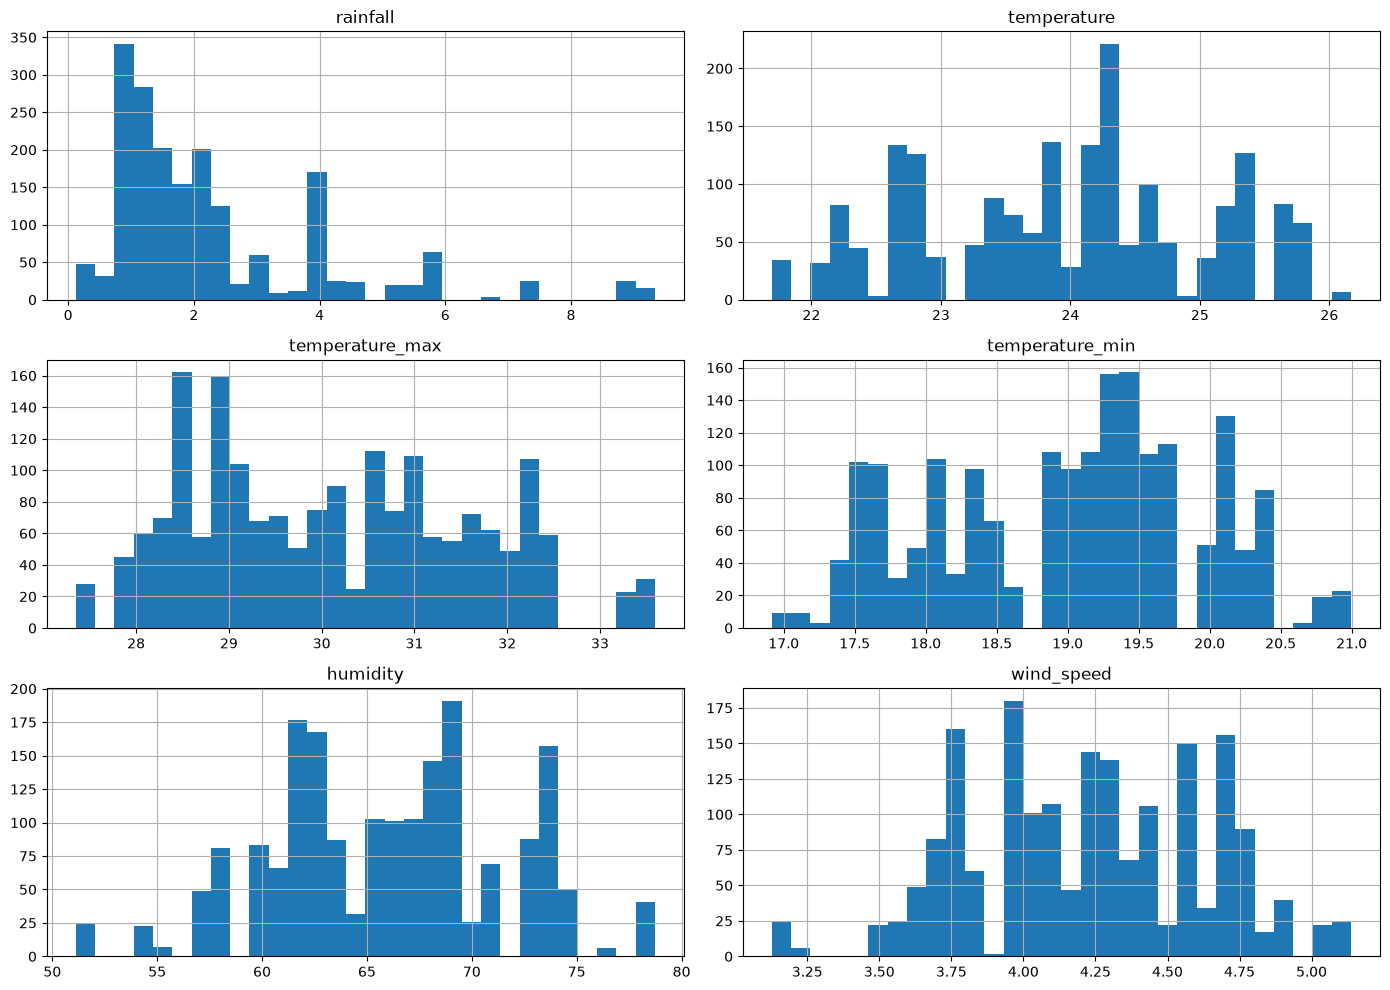

In [150]:
df[weather_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

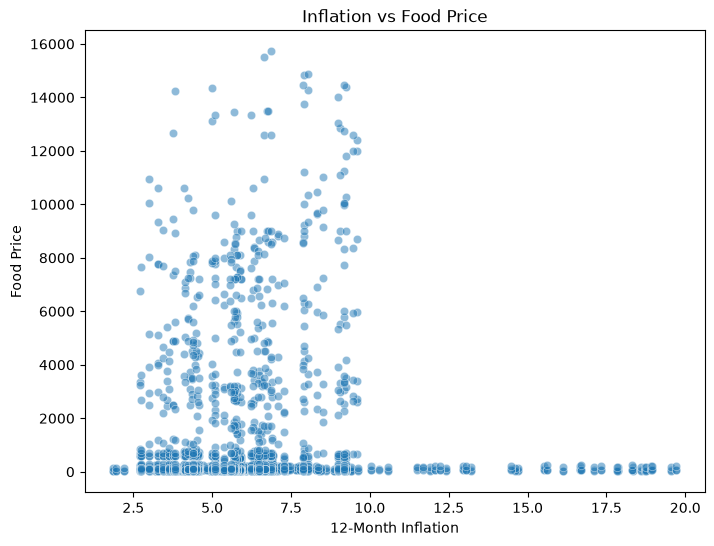

In [151]:
# Inflation and Food Prices

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="inflation_12m",
    y="food_price",
    alpha=0.5
)

plt.title("Inflation vs Food Price")
plt.xlabel("12-Month Inflation")
plt.ylabel("Food Price")

plt.show()

In [152]:
df[
    ["inflation_12m", "food_price"]
].corr()

,inflation_12m,food_price
inflation_12m,1.000000,0.007229
food_price,0.007229,1.000000


In [153]:
# Extreme Price Changes

threshold = df["food_price_change_1m"].abs().quantile(0.99)

extreme_prices = df[
    df["food_price_change_1m"].abs() >= threshold
]

extreme_prices[
    [
        "date",
        "commodity",
        "food_price",
        "food_price_change_1m",
        "target_food_price_next_month"
    ]
].sort_values(
    "food_price_change_1m",
    key=abs,
    ascending=False
).head(20)

,date,commodity,food_price,food_price_change_1m,target_food_price_next_month
1585,2025-04-01,Tomatoes,10628.48,6468.48,4878.080
1609,2025-05-01,Tomatoes,4878.08,-5750.40,4874.880
1478,2024-12-01,Beans (dolichos),10066.50,5566.50,7785.900
1678,2025-09-01,Cowpeas,7200.00,5099.58,7433.500
1730,2025-11-01,Tomatoes,8114.50,5074.50,5180.800
1322,2024-05-01,Beans (dolichos),9600.00,-4742.85,9600.000
1658,2025-08-01,Cowpeas,2100.42,-4599.18,7200.000
1714,2025-10-01,Tomatoes,3040.00,-3588.48,8114.500
1746,2025-12-01,Tomatoes,5180.80,-2933.70,4940.800
1275,2024-03-01,Beans (rosecoco),13446.90,2846.70,13121.100


In [154]:
# Check data leakage

target = "target_food_price_next_month"

print("Target:", target)

possible_leakage = [
    "target_food_price_next_month",
    "target_date"
]

for column in possible_leakage:
    if column in df.columns:
        print(column, "is present")

Target: target_food_price_next_month
target_food_price_next_month is present
target_date is present


In [155]:
df[[
    "date",
    "target_date",
    "food_price",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_ma_3",
    "food_price_ma_6",
    "target_food_price_next_month"
]].head(15)

,date,target_date,food_price,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_ma_3,food_price_ma_6,target_food_price_next_month
0,2006-01-01,2006-02-01,39.0,NaN,NaN,NaN,NaN,39.000000,39.000000,42.0
1,2006-01-01,2006-02-01,23.5,NaN,NaN,NaN,NaN,23.500000,23.500000,25.0
2,2006-01-01,2006-02-01,115.0,NaN,NaN,NaN,NaN,115.000000,115.000000,120.0
3,2006-02-01,2006-03-01,42.0,39.0,NaN,NaN,NaN,40.500000,40.500000,47.0
4,2006-02-01,2006-03-01,25.0,23.5,NaN,NaN,NaN,24.250000,24.250000,24.5
5,2006-02-01,2006-03-01,120.0,115.0,NaN,NaN,NaN,117.500000,117.500000,108.0
6,2006-03-01,2006-04-01,47.0,42.0,NaN,NaN,NaN,42.666667,42.666667,53.0
7,2006-03-01,2006-04-01,24.5,25.0,NaN,NaN,NaN,24.333333,24.333333,26.0
8,2006-03-01,2006-04-01,108.0,120.0,NaN,NaN,NaN,114.333333,114.333333,110.0
9,2006-04-01,2006-05-01,53.0,47.0,39.0,NaN,NaN,47.333333,45.250000,51.0


In [156]:
# Verifyy target date is one month after the current date

expected_target_date = df["date"] + pd.DateOffset(months=1)

date_check = df["target_date"] == expected_target_date

print("Incorrect target dates:", (~date_check).sum())

Incorrect target dates: 0


In [157]:
print(df[["date", "target_date", "food_price", "target_food_price_next_month"]].head(10))

        date target_date  food_price  target_food_price_next_month
0 2006-01-01  2006-02-01        39.0                          42.0
1 2006-01-01  2006-02-01        23.5                          25.0
2 2006-01-01  2006-02-01       115.0                         120.0
3 2006-02-01  2006-03-01        42.0                          47.0
4 2006-02-01  2006-03-01        25.0                          24.5
5 2006-02-01  2006-03-01       120.0                         108.0
6 2006-03-01  2006-04-01        47.0                          53.0
7 2006-03-01  2006-04-01        24.5                          26.0
8 2006-03-01  2006-04-01       108.0                         110.0
9 2006-04-01  2006-05-01        53.0                          51.0


In [158]:
features = [
    "commodity",
    "food_price",
    "inflation_annual_avg",
    "inflation_12m",
    "central_bank_rate",
    "rainfall",
    "temperature",
    "temperature_max",
    "temperature_min",
    "humidity",
    "wind_speed",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_change_1m",
    "food_price_ma_3",
    "food_price_ma_6",
    "central_bank_rate_change_1m"
]

target = "target_food_price_next_month"

In [159]:
missing_features = [column for column in features if column not in df.columns]

print("Missing features:", missing_features)
print("Number of features:", len(features))

Missing features: []
Number of features: 19


In [160]:
df[features + [target]].isnull().sum().sort_values(ascending=False)

food_price_lag_12               291
food_price_lag_6                138
food_price_lag_3                 61
central_bank_rate_change_1m      25
food_price_lag_1                 22
food_price_change_1m             22
food_price                        0
commodity                         0
inflation_12m                     0
inflation_annual_avg              0
temperature                       0
central_bank_rate                 0
wind_speed                        0
humidity                          0
temperature_min                   0
temperature_max                   0
rainfall                          0
food_price_ma_3                   0
food_price_ma_6                   0
target_food_price_next_month      0
dtype: int64

In [161]:
df[df["food_price_lag_12"].isnull()][
    ["date", "commodity", "food_price", "food_price_lag_12"]
].head(20)

,date,commodity,food_price,food_price_lag_12
0,2006-01-01,Beans (dry),39.0,NaN
1,2006-01-01,Maize (white),23.5,NaN
2,2006-01-01,Oil (vegetable),115.0,NaN
3,2006-02-01,Beans (dry),42.0,NaN
4,2006-02-01,Maize (white),25.0,NaN
5,2006-02-01,Oil (vegetable),120.0,NaN
6,2006-03-01,Beans (dry),47.0,NaN
7,2006-03-01,Maize (white),24.5,NaN
8,2006-03-01,Oil (vegetable),108.0,NaN
9,2006-04-01,Beans (dry),53.0,NaN


In [162]:
df.groupby("commodity")["date"].agg(["min", "max", "count"]).sort_values("min")

,min,max,count
commodity,,,
Beans (dry),2006-01-01,2026-07-01,237
Maize (white),2006-01-01,2020-11-01,179
Oil (vegetable),2006-01-01,2026-07-01,233
Bananas,2018-12-01,2026-07-01,58
Sugar,2018-12-01,2026-07-01,58
Salt,2018-12-01,2026-07-01,58
Rice,2018-12-01,2026-07-01,58
Potatoes (Irish),2018-12-01,2026-07-01,58
Wheat flour,2018-12-01,2026-07-01,58


In [163]:
required_lag_features = [
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12"
]

df_model = df.dropna(subset=required_lag_features).copy()

print("Original rows:", len(df))
print("Rows after removing missing lag history:", len(df_model))

Original rows: 1878
Rows after removing missing lag history: 1587


In [164]:
df_model[required_lag_features].isnull().sum()

food_price_lag_1     0
food_price_lag_3     0
food_price_lag_6     0
food_price_lag_12    0
dtype: int64

In [165]:
df_model[features + [target]].isnull().sum().sort_values(ascending=False)

commodity                       0
food_price                      0
inflation_annual_avg            0
inflation_12m                   0
central_bank_rate               0
rainfall                        0
temperature                     0
temperature_max                 0
temperature_min                 0
humidity                        0
wind_speed                      0
food_price_lag_1                0
food_price_lag_3                0
food_price_lag_6                0
food_price_lag_12               0
food_price_change_1m            0
food_price_ma_3                 0
food_price_ma_6                 0
central_bank_rate_change_1m     0
target_food_price_next_month    0
dtype: int64

In [166]:
commodity_counts = (
    df_model["commodity"]
    .value_counts()
    .sort_values()
)

commodity_counts

commodity
Meat (beef)                 25
Beans (rosecoco)            25
Beans (dolichos)            30
Rice (aromatic)             33
Potatoes (Irish, red)       34
Milk (camel, fresh)         39
Cowpeas                     41
Sorghum                     41
Milk (UHT)                  41
Onions (dry)                45
Meat (camel)                45
Maize                       45
Meat (goat)                 45
Salt                        47
Rice                        48
Sugar                       48
Wheat flour                 48
Bananas                     48
Potatoes (Irish, white)     48
Potatoes (Irish)            48
Maize flour                 48
Tomatoes                    50
Maize (white, dry)          52
Maize (white)              167
Oil (vegetable)            221
Beans (dry)                225
Name: count, dtype: int64

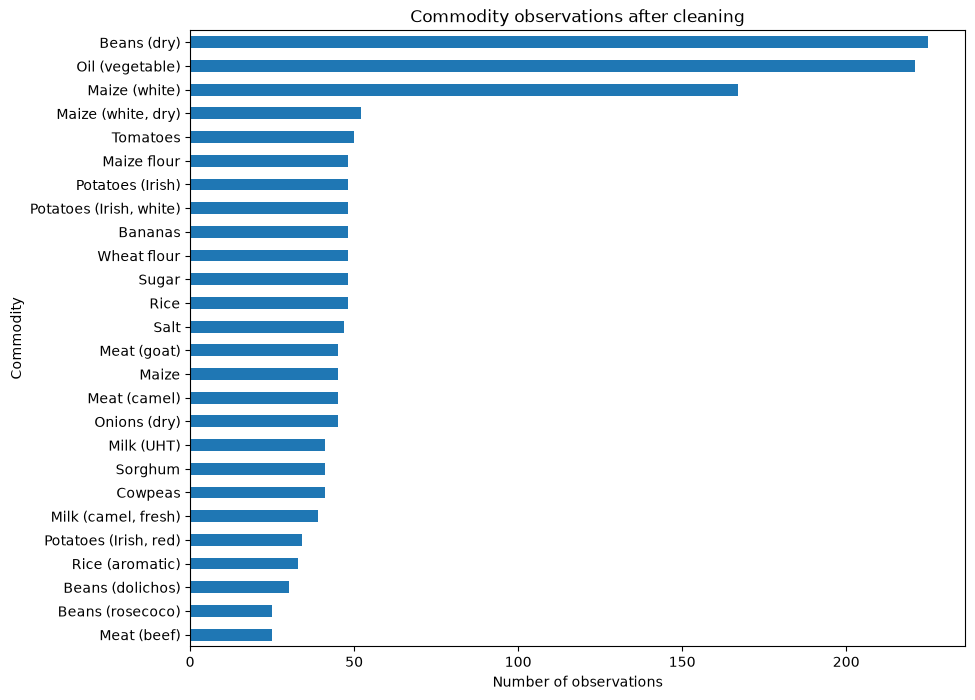

In [167]:
plt.figure(figsize=(10, 8))

commodity_counts.plot(kind="barh")

plt.title("Commodity observations after cleaning")
plt.xlabel("Number of observations")
plt.ylabel("Commodity")
plt.show()

In [168]:
unique_dates = sorted(df_model["date"].unique())

print("Number of dates:", len(unique_dates))
print("First date:", unique_dates[0])
print("Last date:", unique_dates[-1])

Number of dates: 235
First date: 2007-01-01 00:00:00
Last date: 2026-07-01 00:00:00


In [169]:
commodity_dates = df_model.groupby("commodity")["date"].agg(
    ["min", "max", "count"]
)

commodity_dates.sort_values("min")

,min,max,count
commodity,,,
Beans (dry),2007-01-01,2026-07-01,225
Oil (vegetable),2007-01-01,2026-07-01,221
Maize (white),2007-01-01,2020-11-01,167
Bananas,2021-10-01,2026-07-01,48
Sugar,2021-10-01,2026-07-01,48
Rice,2021-10-01,2026-07-01,48
Potatoes (Irish),2021-10-01,2026-07-01,48
Maize flour,2021-10-01,2026-07-01,48
Wheat flour,2021-10-01,2026-07-01,48


In [170]:
latest_start = df_model.groupby("commodity")["date"].min().max()

print("Latest commodity start date:", latest_start)

Latest commodity start date: 2022-02-01 00:00:00


In [171]:
# split the data into training, validation, and test sets based on time series split

train_parts = []
validation_parts = []
test_parts = []

for commodity in df_model["commodity"].unique():

    commodity_data = df_model[
        df_model["commodity"] == commodity
    ].sort_values("date").copy()

    n = len(commodity_data)

    train_end = int(n * 0.70)
    validation_end = int(n * 0.85)

    train_parts.append(
        commodity_data.iloc[:train_end]
    )

    validation_parts.append(
        commodity_data.iloc[train_end:validation_end]
    )

    test_parts.append(
        commodity_data.iloc[validation_end:]
    )

train = pd.concat(train_parts, ignore_index=True)
validation = pd.concat(validation_parts, ignore_index=True)
test = pd.concat(test_parts, ignore_index=True)

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

Training rows: 1097
Validation rows: 237
Test rows: 253


In [172]:
print("Training commodities:", train["commodity"].nunique())
print("Validation commodities:", validation["commodity"].nunique())
print("Test commodities:", test["commodity"].nunique())

Training commodities: 26
Validation commodities: 26
Test commodities: 26


In [173]:
print("Training date range:")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation date range:")
print(validation["date"].min(), "to", validation["date"].max())

print("\nTest date range:")
print(test["date"].min(), "to", test["date"].max())

Training date range:
2007-01-01 00:00:00 to 2025-07-01 00:00:00

Validation date range:
2016-09-01 00:00:00 to 2026-01-01 00:00:00

Test date range:
2018-10-01 00:00:00 to 2026-07-01 00:00:00


In [174]:
check = train.groupby("commodity")["date"].max().to_frame("train_end")

check["validation_start"] = validation.groupby(
    "commodity"
)["date"].min()

check["validation_end"] = validation.groupby(
    "commodity"
)["date"].max()

check["test_start"] = test.groupby(
    "commodity"
)["date"].min()

check

,train_end,validation_start,validation_end,test_start
commodity,,,,
Bananas,2025-04-01,2025-05-01,2025-11-01,2025-12-01
Beans (dolichos),2024-05-01,2024-06-01,2025-01-01,2025-05-01
Beans (dry),2020-01-01,2020-02-01,2023-09-01,2023-10-01
Beans (rosecoco),2024-04-01,2024-05-01,2025-01-01,2025-05-01
Cowpeas,2024-07-01,2024-08-01,2025-01-01,2025-02-01
Maize,2025-05-01,2025-06-01,2025-12-01,2026-01-01
Maize (white),2016-08-01,2016-09-01,2018-09-01,2018-10-01
"Maize (white, dry)",2025-02-01,2025-03-01,2025-10-01,2025-11-01
Maize flour,2025-04-01,2025-05-01,2025-11-01,2025-12-01


In [175]:
X_train = train[features].copy()
y_train = train[target].copy()

X_validation = validation[features].copy()
y_validation = validation[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

In [ ]:
categorical_features = ["commodity"]

numeric_features = [
    column for column in features
    if column not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "commodity",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [177]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Training shape: (1097, 19)
Validation shape: (237, 19)
Test shape: (253, 19)
Numeric features: 18
Categorical features: 1


### Naive forecasting baseline

In [178]:
naive_validation_pred = validation["food_price"].values
naive_test_pred = test["food_price"].values

naive_validation_mae = mean_absolute_error(
    y_validation,
    naive_validation_pred
)

naive_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        naive_validation_pred
    )
)

naive_validation_r2 = r2_score(
    y_validation,
    naive_validation_pred
)

naive_test_mae = mean_absolute_error(
    y_test,
    naive_test_pred
)

naive_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_test_pred
    )
)

naive_test_r2 = r2_score(
    y_test,
    naive_test_pred
)

print("Naive validation MAE:", naive_validation_mae)
print("Naive validation RMSE:", naive_validation_rmse)
print("Naive validation R2:", naive_validation_r2)

print("Naive test MAE:", naive_test_mae)
print("Naive test RMSE:", naive_test_rmse)
print("Naive test R2:", naive_test_r2)

Naive validation MAE: 225.1323628691983
Naive validation RMSE: 767.1611095168103
Naive validation R2: 0.9102198609082983
Naive test MAE: 224.14588932806322
Naive test RMSE: 723.5716937464501
Naive test R2: 0.9322969318687656


In [179]:
baseline_results = pd.DataFrame({
    "Model": ["Naive"],
    "Validation MAE": [naive_validation_mae],
    "Validation RMSE": [naive_validation_rmse],
    "Validation R2": [naive_validation_r2],
    "Test MAE": [naive_test_mae],
    "Test RMSE": [naive_test_rmse],
    "Test R2": [naive_test_r2]
})

baseline_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.16111,0.91022,224.145889,723.571694,0.932297


In [180]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [181]:
rf_validation_pred = rf_pipeline.predict(X_validation)

rf_validation_mae = mean_absolute_error(y_validation, rf_validation_pred)

rf_validation_rmse = np.sqrt(mean_squared_error(y_validation, rf_validation_pred))

rf_validation_r2 = r2_score(y_validation, rf_validation_pred)

print("Random Forest validation MAE:", rf_validation_mae)
print("Random Forest validation RMSE:", rf_validation_rmse)
print("Random Forest validation R2:", rf_validation_r2)

Random Forest validation MAE: 217.62578558063944
Random Forest validation RMSE: 671.0037353548836
Random Forest validation R2: 0.9313157765638629


In [182]:
rf_test_pred = rf_pipeline.predict(
    X_test
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("Random Forest test MAE:", rf_test_mae)
print("Random Forest test RMSE:", rf_test_rmse)
print("Random Forest test R2:", rf_test_r2)

Random Forest test MAE: 254.34287510293763
Random Forest test RMSE: 721.4011792124261
Random Forest test R2: 0.9327025035329685


In [183]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Validation MAE": [rf_validation_mae],
    "Validation RMSE": [rf_validation_rmse],
    "Validation R2": [rf_validation_r2],
    "Test MAE": [rf_test_mae],
    "Test RMSE": [rf_test_rmse],
    "Test R2": [rf_test_r2]
})

model_results = pd.concat(
    [baseline_results, rf_results],
    ignore_index=True
)

model_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.161110,0.910220,224.145889,723.571694,0.932297
1,Random Forest,217.625786,671.003735,0.931316,254.342875,721.401179,0.932703


In [184]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [185]:
xgb_validation_pred = xgb_pipeline.predict(
    X_validation
)

xgb_validation_mae = mean_absolute_error(
    y_validation,
    xgb_validation_pred
)

xgb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_validation_pred
    )
)

xgb_validation_r2 = r2_score(
    y_validation,
    xgb_validation_pred
)

print("XGBoost validation MAE:", xgb_validation_mae)
print("XGBoost validation RMSE:", xgb_validation_rmse)
print("XGBoost validation R2:", xgb_validation_r2)

XGBoost validation MAE: 213.5287891801601
XGBoost validation RMSE: 576.843043844771
XGBoost validation R2: 0.9492399038112298


In [186]:
xgb_test_pred = xgb_pipeline.predict(
    X_test
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print("XGBoost test MAE:", xgb_test_mae)
print("XGBoost test RMSE:", xgb_test_rmse)
print("XGBoost test R2:", xgb_test_r2)

XGBoost test MAE: 273.14375696823066
XGBoost test RMSE: 795.0338109039998
XGBoost test R2: 0.9182634298665412


In [187]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Validation MAE": [xgb_validation_mae],
    "Validation RMSE": [xgb_validation_rmse],
    "Validation R2": [xgb_validation_r2],
    "Test MAE": [xgb_test_mae],
    "Test RMSE": [xgb_test_rmse],
    "Test R2": [xgb_test_r2]
})

model_results = pd.concat(
    [baseline_results, rf_results, xgb_results],
    ignore_index=True
)

model_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.161110,0.910220,224.145889,723.571694,0.932297
1,Random Forest,217.625786,671.003735,0.931316,254.342875,721.401179,0.932703
2,XGBoost,213.528789,576.843044,0.949240,273.143757,795.033811,0.918263


In [188]:
test_comparison = test[["date", "commodity", "food_price", target]].copy()

test_comparison["naive_predicted"] = naive_test_pred
test_comparison["rf_predicted"] = rf_test_pred
test_comparison["xgb_predicted"] = xgb_test_pred

commodity_results = []

for commodity in test_comparison["commodity"].unique():

    data = test_comparison[
        test_comparison["commodity"] == commodity
    ]

    commodity_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["naive_predicted"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["rf_predicted"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["xgb_predicted"]
        )
    })

commodity_results = pd.DataFrame(commodity_results)

commodity_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE
0,Beans (dry),9.698235,9.785861,12.260466
1,Maize (white),3.273077,3.937057,4.868972
2,Oil (vegetable),10.653235,38.785500,41.161646
3,Bananas,3.777500,4.911802,4.777100
4,Maize flour,7.013125,6.408882,7.026594
5,Potatoes (Irish),9.478750,8.763719,8.319321
6,Rice,6.300000,5.593058,6.163229
7,Sugar,17.805000,19.080375,18.515079
8,Wheat flour,3.475625,6.353213,4.160252
9,Salt,2.340000,1.328675,1.719203


In [189]:
commodity_results["Best Model"] = commodity_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

commodity_results["Best Model"] = commodity_results[
    "Best Model"
].str.replace(" MAE", "")

commodity_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),9.698235,9.785861,12.260466,Naive
1,Maize (white),3.273077,3.937057,4.868972,Naive
2,Oil (vegetable),10.653235,38.785500,41.161646,Naive
3,Bananas,3.777500,4.911802,4.777100,Naive
4,Maize flour,7.013125,6.408882,7.026594,Random Forest
5,Potatoes (Irish),9.478750,8.763719,8.319321,XGBoost
6,Rice,6.300000,5.593058,6.163229,Random Forest
7,Sugar,17.805000,19.080375,18.515079,Naive
8,Wheat flour,3.475625,6.353213,4.160252,Naive
9,Salt,2.340000,1.328675,1.719203,Random Forest


In [190]:
commodity_results["Best Model"].value_counts()

Best Model
Naive            16
Random Forest     5
XGBoost           5
Name: count, dtype: int64

In [191]:
validation_comparison = validation[
    ["date", "commodity", target]
].copy()

validation_comparison["Naive"] = naive_validation_pred
validation_comparison["Random Forest"] = rf_validation_pred
validation_comparison["XGBoost"] = xgb_validation_pred

validation_results = []

for commodity in validation_comparison["commodity"].unique():

    data = validation_comparison[
        validation_comparison["commodity"] == commodity
    ]

    validation_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

validation_results = pd.DataFrame(validation_results)

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE
0,Beans (dry),6.824118,6.117525,7.112490
1,Maize (white),3.420000,3.485910,3.968387
2,Oil (vegetable),10.904091,18.315397,21.149478
3,Bananas,2.857143,2.598405,3.482799
4,Maize flour,3.121429,3.723016,5.362721
5,Potatoes (Irish),10.292143,12.016685,13.124074
6,Rice,4.637143,7.693217,22.581928
7,Sugar,6.166429,17.428354,15.058575
8,Wheat flour,8.736429,9.292548,9.278561
9,Salt,1.580000,2.528701,2.277477


In [192]:
validation_results["Best Model"] = validation_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

validation_results["Best Model"] = validation_results[
    "Best Model"
].str.replace(" MAE", "")

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),6.824118,6.117525,7.112490,Random Forest
1,Maize (white),3.420000,3.485910,3.968387,Naive
2,Oil (vegetable),10.904091,18.315397,21.149478,Naive
3,Bananas,2.857143,2.598405,3.482799,Random Forest
4,Maize flour,3.121429,3.723016,5.362721,Naive
5,Potatoes (Irish),10.292143,12.016685,13.124074,Naive
6,Rice,4.637143,7.693217,22.581928,Naive
7,Sugar,6.166429,17.428354,15.058575,Naive
8,Wheat flour,8.736429,9.292548,9.278561,Naive
9,Salt,1.580000,2.528701,2.277477,Naive


In [193]:
validation_results["Best Model"].value_counts()

Best Model
Naive            14
Random Forest     8
XGBoost           4
Name: count, dtype: int64

In [ ]:
rf_configs = {
    "RF_1": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 2
    },
    "RF_2": {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 2
    },
    "RF_3": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 1
    },
    "RF_4": {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 1
    }
}

rf_tuning_results = []

for name, config in rf_configs.items():

    model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_validation)

    mae = mean_absolute_error(y_validation, predictions)

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    r2 = r2_score(
        y_validation,
        predictions
    )

    rf_tuning_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

rf_tuning_results

,Model,MAE,RMSE,R2
0,RF_1,217.625786,671.003735,0.931316
1,RF_2,217.687939,670.841590,0.931349
2,RF_3,217.076583,664.649842,0.932610
3,RF_4,219.636463,667.966626,0.931936


In [195]:
best_rf_config = rf_tuning_results.loc[
    rf_tuning_results["MAE"].idxmin()
]

best_rf_config

Model          RF_3
MAE      217.076583
RMSE     664.649842
R2          0.93261
Name: 2, dtype: object

In [196]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [197]:
rf_validation_pred = rf_pipeline.predict(X_validation)

rf_test_pred = rf_pipeline.predict(X_test)

In [198]:
validation_comparison = validation[
    ["date", "commodity", target]
].copy()

validation_comparison["Naive"] = naive_validation_pred
validation_comparison["Random Forest"] = rf_validation_pred
validation_comparison["XGBoost"] = xgb_validation_pred

validation_results = []

for commodity in validation_comparison["commodity"].unique():

    data = validation_comparison[
        validation_comparison["commodity"] == commodity
    ]

    validation_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

validation_results = pd.DataFrame(validation_results)

validation_results["Best Model"] = validation_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

validation_results["Best Model"] = validation_results["Best Model"].str.replace(" MAE", "")

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),6.824118,5.937159,7.112490,Random Forest
1,Maize (white),3.420000,3.417775,3.968387,Random Forest
2,Oil (vegetable),10.904091,19.868588,21.149478,Naive
3,Bananas,2.857143,2.600647,3.482799,Random Forest
4,Maize flour,3.121429,3.829650,5.362721,Naive
5,Potatoes (Irish),10.292143,12.022855,13.124074,Naive
6,Rice,4.637143,7.658556,22.581928,Naive
7,Sugar,6.166429,16.212732,15.058575,Naive
8,Wheat flour,8.736429,9.387585,9.278561,Naive
9,Salt,1.580000,2.510375,2.277477,Naive


In [199]:
validation_results["Best Model"].value_counts()

Best Model
Naive            13
Random Forest     9
XGBoost           4
Name: count, dtype: int64

In [200]:
train_validation = pd.concat(
    [train, validation],
    ignore_index=True
)

X_train_validation = train_validation[features].copy()
y_train_validation = train_validation[target].copy()

X_train_validation.shape

(1334, 19)

In [201]:
final_rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_rf_model)
    ]
)

final_rf_pipeline.fit(X_train_validation,y_train_validation)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [202]:
final_xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_xgb_model)
    ]
)

final_xgb_pipeline.fit(X_train_validation, y_train_validation)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [203]:
final_rf_test_pred = final_rf_pipeline.predict(X_test)

final_xgb_test_pred = final_xgb_pipeline.predict(X_test)

final_naive_test_pred = test["food_price"].values

In [204]:
final_results = []

models = {
    "Naive": final_naive_test_pred,
    "Random Forest": final_rf_test_pred,
    "XGBoost": final_xgb_test_pred
}

for name, predictions in models.items():

    final_results.append({
        "Model": name,
        "MAE": mean_absolute_error(
            y_test,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        ),
        "R2": r2_score(
            y_test,
            predictions
        )
    })

final_results = pd.DataFrame(final_results)

final_results

,Model,MAE,RMSE,R2
0,Naive,224.145889,723.571694,0.932297
1,Random Forest,226.982710,670.976313,0.941782
2,XGBoost,245.379085,685.967840,0.939151


In [205]:
final_results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
0,Naive,224.145889,723.571694,0.932297
1,Random Forest,226.982710,670.976313,0.941782
2,XGBoost,245.379085,685.967840,0.939151


In [206]:
final_test_comparison = test[
    ["date", "commodity", target]
].copy()

final_test_comparison["Naive"] = final_naive_test_pred
final_test_comparison["Random Forest"] = final_rf_test_pred
final_test_comparison["XGBoost"] = final_xgb_test_pred

final_test_results = []

for commodity in final_test_comparison["commodity"].unique():

    data = final_test_comparison[
        final_test_comparison["commodity"] == commodity
    ]

    final_test_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

final_test_results = pd.DataFrame(
    final_test_results
)

final_test_results["Best Model"] = final_test_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

final_test_results["Best Model"] = final_test_results[
    "Best Model"
].str.replace(" MAE", "")

final_test_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),9.698235,9.168605,9.686096,Random Forest
1,Maize (white),3.273077,4.131503,4.889100,Naive
2,Oil (vegetable),10.653235,16.653137,17.666915,Naive
3,Bananas,3.777500,4.483232,4.769664,Naive
4,Maize flour,7.013125,6.731990,7.228137,Random Forest
5,Potatoes (Irish),9.478750,7.969311,9.870065,Random Forest
6,Rice,6.300000,5.758736,7.372267,Random Forest
7,Sugar,17.805000,19.138229,19.902166,Naive
8,Wheat flour,3.475625,5.332250,4.246200,Naive
9,Salt,2.340000,1.802552,1.673661,XGBoost


In [207]:
final_test_results["Best Model"].value_counts()

Best Model
Naive            16
Random Forest     8
XGBoost           2
Name: count, dtype: int64

* Random Forest achieved a test MAE of 226.98, RMSE of 670.98, and R² of 0.9418 for one-month-ahead food price forecasting.

* The Naive baseline achieved MAE 224.15, demonstrating how strong price persistence is

* RF performs better for Beans (dry), Maize flour, Potatoes (Irish), Rice, Tomatoes and Cowpeas.
* Naive is particularly strong for many commodities.
* XGBoost only wins Salt and Beans (rosecoco) on the final test.

In [208]:
rf_model_fitted = final_rf_pipeline.named_steps["model"]
preprocessor_fitted = final_rf_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model_fitted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
41,numeric__food_price_ma_3,0.598290
26,numeric__food_price,0.288842
37,numeric__food_price_lag_3,0.052863
42,numeric__food_price_ma_6,0.024294
36,numeric__food_price_lag_1,0.014233
38,numeric__food_price_lag_6,0.005976
39,numeric__food_price_lag_12,0.003414
40,numeric__food_price_change_1m,0.001664
28,numeric__inflation_12m,0.001496
27,numeric__inflation_annual_avg,0.001493


In [209]:
actual_vs_predicted = test[
    ["date", "commodity", target]
].copy()

actual_vs_predicted["actual"] = y_test.values
actual_vs_predicted["predicted"] = final_rf_test_pred

actual_vs_predicted["error"] = (
    actual_vs_predicted["actual"]
    - actual_vs_predicted["predicted"]
)

actual_vs_predicted["absolute_error"] = (
    actual_vs_predicted["error"].abs()
)

actual_vs_predicted.head(20)

,date,commodity,target_food_price_next_month,actual,predicted,error,absolute_error
0,2023-10-01,Beans (dry),194.620,194.620,179.351371,15.268629,15.268629
1,2023-11-01,Beans (dry),188.950,188.950,193.097849,-4.147849,4.147849
2,2023-12-01,Beans (dry),182.500,182.500,179.877629,2.622371,2.622371
3,2024-01-01,Beans (dry),190.000,190.000,181.558390,8.441610,8.441610
4,2024-02-01,Beans (dry),180.000,180.000,188.687045,-8.687045,8.687045
5,2024-03-01,Beans (dry),160.000,160.000,170.067594,-10.067594,10.067594
6,2024-04-01,Beans (dry),165.000,165.000,167.456827,-2.456827,2.456827
7,2024-05-01,Beans (dry),145.820,145.820,166.985904,-21.165904,21.165904
8,2024-06-01,Beans (dry),142.860,142.860,144.217182,-1.357182,1.357182
9,2024-07-01,Beans (dry),141.920,141.920,137.947119,3.972881,3.972881


In [210]:
actual_vs_predicted[
    [
        "date",
        "commodity",
        "actual",
        "predicted",
        "error",
        "absolute_error"
    ]
].head(20).round(2)

,date,commodity,actual,predicted,error,absolute_error
0,2023-10-01,Beans (dry),194.62,179.35,15.27,15.27
1,2023-11-01,Beans (dry),188.95,193.10,-4.15,4.15
2,2023-12-01,Beans (dry),182.50,179.88,2.62,2.62
3,2024-01-01,Beans (dry),190.00,181.56,8.44,8.44
4,2024-02-01,Beans (dry),180.00,188.69,-8.69,8.69
5,2024-03-01,Beans (dry),160.00,170.07,-10.07,10.07
6,2024-04-01,Beans (dry),165.00,167.46,-2.46,2.46
7,2024-05-01,Beans (dry),145.82,166.99,-21.17,21.17
8,2024-06-01,Beans (dry),142.86,144.22,-1.36,1.36
9,2024-07-01,Beans (dry),141.92,137.95,3.97,3.97


In [211]:
actual_vs_predicted.sort_values(
    "absolute_error",
    ascending=False
).head(20).round(2)

,date,commodity,target_food_price_next_month,actual,predicted,error,absolute_error
243,2025-07-01,Cowpeas,2100.42,2100.42,7185.51,-5085.09,5085.09
235,2026-02-01,Beans (dolichos),13500.00,13500.00,9396.52,4103.48,4103.48
237,2025-06-01,Beans (rosecoco),9349.20,9349.20,13385.55,-4036.35,4036.35
228,2026-04-01,Tomatoes,8731.52,8731.52,6476.81,2254.71,2254.71
236,2025-05-01,Beans (rosecoco),14231.25,14231.25,11987.22,2244.03,2244.03
238,2026-01-01,Beans (rosecoco),11600.00,11600.00,9475.63,2124.37,2124.37
234,2026-01-01,Beans (dolichos),10250.10,10250.10,8152.11,2097.99,2097.99
229,2026-05-01,Tomatoes,6856.96,6856.96,8759.82,-1902.86,1902.86
218,2024-07-01,Rice (aromatic),9500.00,9500.00,7607.84,1892.16,1892.16
181,2026-05-01,"Maize (white, dry)",5599.80,5599.80,3736.88,1862.92,1862.92


In [212]:
actual_vs_predicted[
    ["actual", "predicted", "error", "absolute_error"]
].describe().round(2)

,actual,predicted,error,absolute_error
count,253.00,253.00,253.00,253.00
mean,1466.57,1455.37,11.20,226.98
std,2786.36,2692.87,672.21,632.67
min,9.89,14.03,-5085.09,0.03
25%,80.00,81.83,-13.49,3.40
50%,150.00,159.13,-1.24,11.28
75%,716.67,764.17,8.71,65.60
max,14231.25,13385.55,4103.48,5085.09


In [213]:
from sklearn.metrics import mean_absolute_percentage_error

final_mape = mean_absolute_percentage_error(
    y_test,
    final_rf_test_pred
) * 100

final_mape

11.985634579225586

In [214]:
final_results["MAPE"] = [
    mean_absolute_percentage_error(
        y_test,
        final_naive_test_pred
    ) * 100,

    mean_absolute_percentage_error(
        y_test,
        final_rf_test_pred
    ) * 100,

    mean_absolute_percentage_error(
        y_test,
        final_xgb_test_pred
    ) * 100
]

final_results

,Model,MAE,RMSE,R2,MAPE
0,Naive,224.145889,723.571694,0.932297,10.714175
1,Random Forest,226.982710,670.976313,0.941782,11.985635
2,XGBoost,245.379085,685.967840,0.939151,12.663203


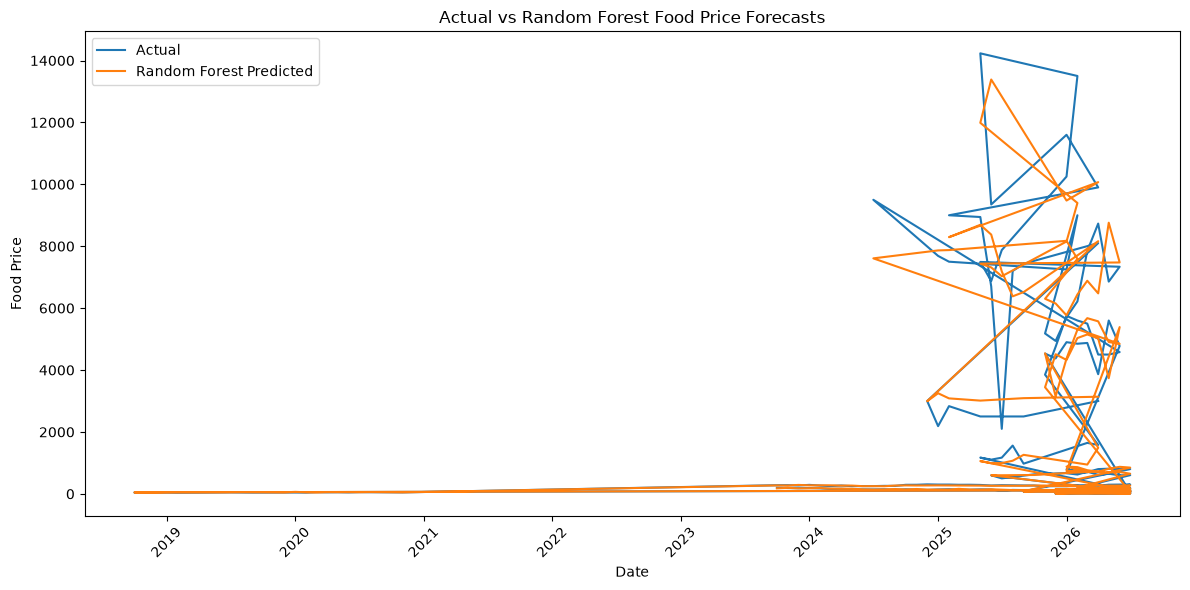

In [217]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test["date"],
    final_rf_test_pred,
    label="Random Forest Predicted"
)

plt.xlabel("Date")
plt.ylabel("Food Price")
plt.title("Actual vs Random Forest Food Price Forecasts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "food_price_forecast.joblib"

joblib.dump(
    final_rf_pipeline,
    model_path
)

print("Model saved to:", model_path)

Model saved to: ..\data\models\food_price_forecast.joblib


In [ ]:
metadata = {
    "model": "RandomForestRegressor",
    "model_version": "1.0",
    "target": target,
    "features": features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "training_rows": len(train_validation),
    "test_rows": len(test),
    "test_mae": 226.982710,
    "test_rmse": 670.976313,
    "test_r2": 0.941782,
    "test_mape": 11.985635,
    "hyperparameters": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 1,
        "random_state": 42
    }
}

metadata_path = model_dir / "food_price_forecast_metadata.json"

with open(metadata_path, "w") as file:
    json.dump(
        metadata,
        file,
        indent=4
    )

print("Metadata saved to:", metadata_path)

Metadata saved to: ..\data\models\food_price_forecast_metadata.json


In [ ]:
loaded_model = joblib.load(
    "../data/models/food_price_forecast.joblib"
)

loaded_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

loaded_prediction

array([179.35137137, 193.0978492 , 179.87762853, 181.55839014,
       188.68704456])